In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/mlp-term-1-2026-kaggle-assignment-1/sample_submission.csv
/kaggle/input/competitions/mlp-term-1-2026-kaggle-assignment-1/train.csv
/kaggle/input/competitions/mlp-term-1-2026-kaggle-assignment-1/test.csv


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
from sklearn.model_selection import train_test_split , GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score

In [4]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor

In [5]:
train_df = pd.read_csv('/kaggle/input/competitions/mlp-term-1-2026-kaggle-assignment-1/train.csv')

In [6]:
test_df = pd.read_csv('/kaggle/input/competitions/mlp-term-1-2026-kaggle-assignment-1/test.csv')

In [7]:
train_df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,extra,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,0,2023-06-28 17:31:46,2023-06-28 18:22:12,1.0,1.50,1.0,N,212,237,Credit Card,5.0,6.533210,0.0,1.0,24.80,2.5,0.0
1,0,2023-06-29 19:15:55,2023-06-29 19:07:31,1.0,3.80,1.0,N,6,163,Credit Card,5.0,9.187048,0.0,1.0,31.55,2.5,0.0
2,1,2023-06-30 18:28:50,2023-06-30 18:01:19,2.0,1.89,1.0,N,35,81,Credit Card,2.5,6.793777,0.0,1.0,24.84,2.5,0.0
3,1,2023-06-30 22:57:37,2023-06-30 22:55:34,1.0,1.10,1.0,N,46,99,Credit Card,1.0,3.695121,0.0,1.0,13.45,2.5,0.0
4,1,2023-06-28 18:39:16,2023-06-28 17:31:29,2.0,2.84,1.0,N,213,114,Credit Card,2.5,7.838753,0.0,1.0,29.88,2.5,0.0


In [8]:
train_df.shape

(10000, 17)

Criteria one for finding datatype for columns

In [9]:
columns = list(train_df.columns)
for i in range(len(columns)):
    print(i,columns[i],'---->',train_df[columns[i]].dtype)

0 VendorID ----> int64
1 tpep_pickup_datetime ----> object
2 tpep_dropoff_datetime ----> object
3 passenger_count ----> float64
4 trip_distance ----> float64
5 RatecodeID ----> float64
6 store_and_fwd_flag ----> object
7 PULocationID ----> int64
8 DOLocationID ----> int64
9 payment_type ----> object
10 extra ----> float64
11 tip_amount ----> float64
12 tolls_amount ----> float64
13 improvement_surcharge ----> float64
14 total_amount ----> float64
15 congestion_surcharge ----> float64
16 Airport_fee ----> float64


Criteria 2 --> Descriptive Statistics on numerical columns

In [10]:
train_df.describe()

,VendorID,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,extra,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
count,10000.000000,9634.000000,10000.000000,9634.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,9634.000000,9634.000000
mean,0.729100,1.357276,3.679527,1.450695,132.710800,132.33240,1.940950,6.094658,0.664425,0.979490,29.740157,2.238426,0.161122
std,0.444672,0.883676,4.905798,5.988978,75.789597,75.95944,1.945885,4.438894,2.441070,0.200076,26.256398,0.834189,0.512859
min,0.000000,0.000000,0.000000,1.000000,1.000000,1.00000,-7.500000,0.000713,-26.550000,-1.000000,-129.300000,-2.500000,-1.750000
25%,0.000000,1.000000,1.070000,1.000000,67.000000,68.00000,0.000000,3.466789,0.000000,1.000000,16.300000,2.500000,0.000000
50%,1.000000,1.000000,1.820000,1.000000,133.000000,132.00000,1.750000,5.208233,0.000000,1.000000,21.360000,2.500000,0.000000
75%,1.000000,1.000000,3.630000,1.000000,198.000000,199.00000,2.500000,7.455228,0.000000,1.000000,31.800000,2.500000,0.000000
max,2.000000,6.000000,71.940000,99.000000,264.000000,264.00000,11.750000,84.032617,32.050000,1.000000,551.000000,2.500000,1.750000


Criteria 3 --> Handling Missing Value(EDA)

In [11]:
train_df.isnull().sum()
#there are 366 out of 10000 missing values in column ['passenger_count','RatecodeID','store_and_fwd_flag','congestion_surcharge','Airport_fee']

VendorID                   0
tpep_pickup_datetime       0
tpep_dropoff_datetime      0
passenger_count          366
trip_distance              0
RatecodeID               366
store_and_fwd_flag       366
PULocationID               0
DOLocationID               0
payment_type               0
extra                      0
tip_amount                 0
tolls_amount               0
improvement_surcharge      0
total_amount               0
congestion_surcharge     366
Airport_fee              366
dtype: int64

Dropping unnecessary columns

In [12]:
columns_to_drop = ['store_and_fwd_flag', 'passenger_count', 'VendorID']

train_df = train_df.drop(columns=columns_to_drop)
test_df = test_df.drop(columns=columns_to_drop)

Preprocessing the features (forming new insights(features) from old features and drop old features)

In [13]:
def preprocess_features(df):
    df_eng = df.copy()
    
    df_eng['tpep_pickup_datetime'] = pd.to_datetime(df_eng['tpep_pickup_datetime'])
    df_eng['tpep_dropoff_datetime'] = pd.to_datetime(df_eng['tpep_dropoff_datetime'])
    
    df_eng['duration_mins'] = ((df_eng['tpep_dropoff_datetime'] - df_eng['tpep_pickup_datetime']).dt.total_seconds() / 60.0).abs()
    df_eng['pickup_hour'] = df_eng['tpep_pickup_datetime'].dt.hour
    df_eng['pickup_dayofweek'] = df_eng['tpep_pickup_datetime'].dt.dayofweek

    df_eng['is_rush_hour'] = df_eng['pickup_hour'].isin([7, 8, 9, 17, 18, 19]).astype(int)
    df_eng['is_night']     = df_eng['pickup_hour'].isin([22, 23, 0, 1, 2, 3, 4, 5]).astype(int)
    df_eng['is_weekend']   = (df_eng['pickup_dayofweek'] >= 5).astype(int)

    df_eng['log_distance'] = np.log1p(df_eng['trip_distance'].clip(lower=0))
    df_eng['log_duration'] = np.log1p(df_eng['duration_mins'].clip(lower=0))

    df_eng['dist_per_min'] = np.where(
        df_eng['duration_mins'] > 0,
        df_eng['trip_distance'] / df_eng['duration_mins'],
        0
    )

    df_eng['same_zone'] = (df_eng['PULocationID'] == df_eng['DOLocationID']).astype(int)

    df_eng['known_fees'] = (
        df_eng['tip_amount'].fillna(0) +
        df_eng['extra'].fillna(0) +
        df_eng['tolls_amount'].fillna(0) +
        df_eng['improvement_surcharge'].fillna(0) +
        df_eng['congestion_surcharge'].fillna(0) +
        df_eng['Airport_fee'].fillna(0)
    )

    df_eng['is_reversal'] = (
        (df_eng['extra'] < 0) | (df_eng['tolls_amount'] < 0)
    ).astype(int)

    df_eng['signed_distance'] = np.where(
        df_eng['is_reversal'] == 1,
        -df_eng['trip_distance'],
        df_eng['trip_distance']
    )
    
    df_eng = df_eng.drop(columns=['tpep_pickup_datetime', 'tpep_dropoff_datetime'])
    return df_eng

In [14]:
train_processed = preprocess_features(train_df)
test_processed = preprocess_features(test_df)
train_processed.shape

(10000, 25)

Identifying Duplicates and dropping if exist

In [15]:
duplicate_count = train_processed.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_count}")
# There are no duplicated rows so there is nothing to drop 

Number of duplicate rows found: 0


Identifying Outliers 

In [16]:
train_processed.describe() 

,trip_distance,RatecodeID,PULocationID,DOLocationID,extra,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,...,is_rush_hour,is_night,is_weekend,log_distance,log_duration,dist_per_min,same_zone,known_fees,is_reversal,signed_distance
count,10000.000000,9634.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,9634.000000,...,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,3.679527,1.450695,132.710800,132.33240,1.940950,6.094658,0.664425,0.979490,29.740157,2.238426,...,0.337000,0.185000,0.003900,1.225920,3.428626,0.435638,0.00380,11.991248,0.005900,3.639721
std,4.905798,5.988978,75.789597,75.95944,1.945885,4.438894,2.441070,0.200076,26.256398,0.834189,...,0.472709,0.388317,0.062331,0.716627,0.980172,5.161522,0.06153,6.888970,0.076588,4.935406
min,0.000000,1.000000,1.000000,1.00000,-7.500000,0.000713,-26.550000,-1.000000,-129.300000,-2.500000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,-35.271633,0.000000,-24.610000
25%,1.070000,1.000000,67.000000,68.00000,0.000000,3.466789,0.000000,1.000000,16.300000,2.500000,...,0.000000,0.000000,0.000000,0.727549,2.905078,0.026395,0.00000,8.233330,0.000000,1.060000
50%,1.820000,1.000000,133.000000,132.00000,1.750000,5.208233,0.000000,1.000000,21.360000,2.500000,...,0.000000,0.000000,0.000000,1.036737,3.633411,0.061819,0.00000,10.689818,0.000000,1.805000
75%,3.630000,1.000000,198.000000,199.00000,2.500000,7.455228,0.000000,1.000000,31.800000,2.500000,...,1.000000,0.000000,0.000000,1.532557,4.157515,0.171941,0.00000,13.380506,0.000000,3.610000
max,71.940000,99.000000,264.000000,264.00000,11.750000,84.032617,32.050000,1.000000,551.000000,2.500000,...,1.000000,1.000000,1.000000,4.289637,7.302889,376.000000,1.00000,91.032617,1.000000,71.940000


Visualizing ouliers (scatter_plot)

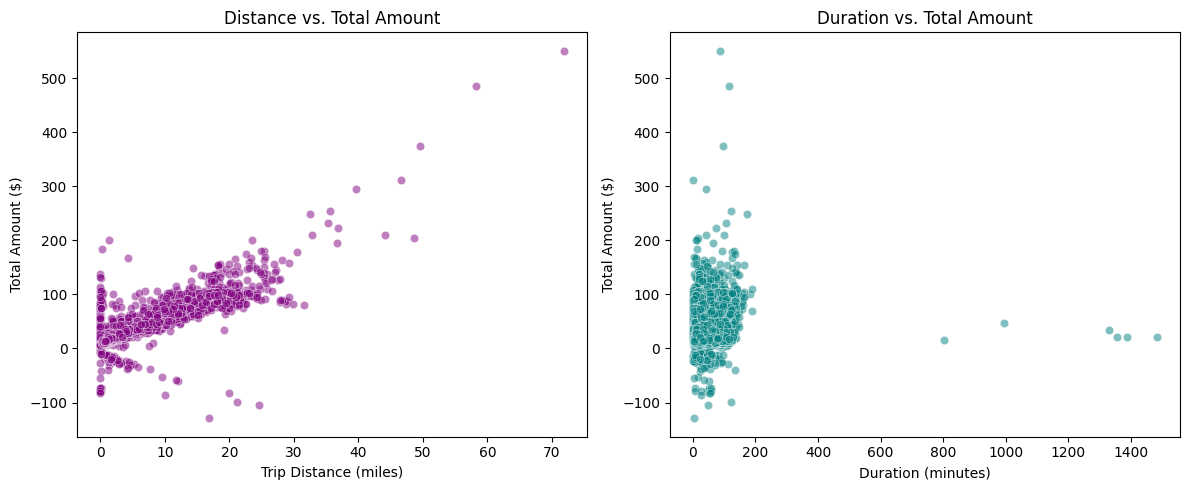

In [17]:
plt.figure(figsize=(12, 5))

# Seaborn Scatter 1: Distance vs Fare
plt.subplot(1, 2, 1)
sns.scatterplot(x='trip_distance', y='total_amount', data=train_processed, color='purple', alpha=0.5)
plt.title('Distance vs. Total Amount')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Total Amount ($)')

# Seaborn Scatter 2: Duration vs Fare
plt.subplot(1, 2, 2)
sns.scatterplot(x='duration_mins', y='total_amount', data=train_processed, color='teal', alpha=0.5)
plt.title('Duration vs. Total Amount')
plt.xlabel('Duration (minutes)')
plt.ylabel('Total Amount ($)')

plt.tight_layout()
plt.show()

In [18]:
#but there are still NA(missing values in the dataset) 
train_processed.isna().sum()

trip_distance              0
RatecodeID               366
PULocationID               0
DOLocationID               0
payment_type               0
extra                      0
tip_amount                 0
tolls_amount               0
improvement_surcharge      0
total_amount               0
congestion_surcharge     366
Airport_fee              366
duration_mins              0
pickup_hour                0
pickup_dayofweek           0
is_rush_hour               0
is_night                   0
is_weekend                 0
log_distance               0
log_duration               0
dist_per_min               0
same_zone                  0
known_fees                 0
is_reversal                0
signed_distance            0
dtype: int64

Visualization

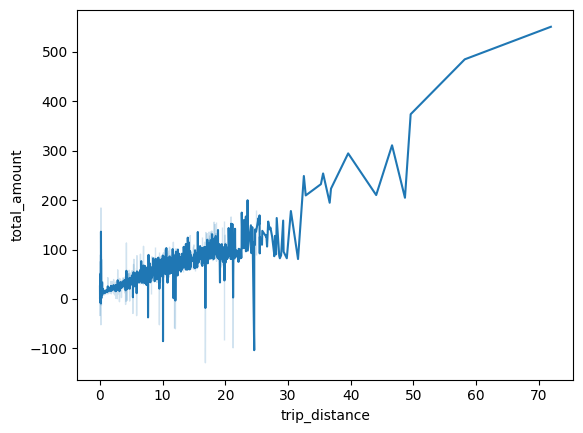

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.lineplot(x='trip_distance', y='total_amount', data=train_processed)

# Show the plot
plt.show()

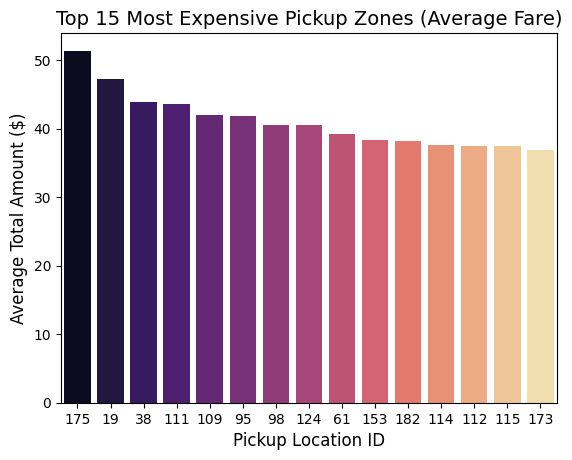

In [20]:
top_locations = train_processed.groupby('PULocationID')['total_amount'].mean().sort_values(ascending=False).head(15).reset_index()
top_locations['PULocationID'] = top_locations['PULocationID'].astype(str)

sns.barplot(x='PULocationID', y='total_amount', data=top_locations, palette='magma')

plt.title('Top 15 Most Expensive Pickup Zones (Average Fare)', fontsize=14)
plt.xlabel('Pickup Location ID', fontsize=12)
plt.ylabel('Average Total Amount ($)', fontsize=12)
plt.show()

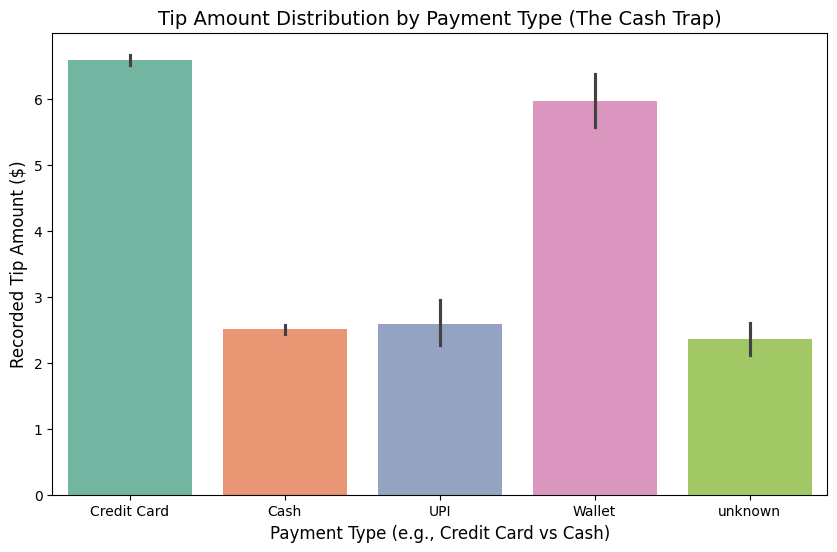

In [21]:
plt.figure(figsize=(10, 6))

# We filter out crazy $100 tips just so the boxes are easy to read
viz_tips = train_processed[train_processed['tip_amount'] < 20]

# Boxplot shows the median and spread of tips
sns.barplot(x='payment_type', y='tip_amount', data=viz_tips, palette='Set2')

plt.title('Tip Amount Distribution by Payment Type (The Cash Trap)', fontsize=14)
plt.xlabel('Payment Type (e.g., Credit Card vs Cash)', fontsize=12)
plt.ylabel('Recorded Tip Amount ($)', fontsize=12)
plt.show()

Pipeline for numerical and categorical data

In [22]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [23]:
# 2. Categorical Pipeline
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # Fills missing Ratecodes with the most common one
    ('onehot', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

In [24]:
# 3.
categorical_cols = ['RatecodeID' , 'payment_type']
numeric_cols = [cols for cols in train_processed.columns if cols not in categorical_cols + ['total_amount'] ]
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])


In [25]:
X = train_processed[numeric_cols + categorical_cols] #feature matrix
y = train_processed['total_amount'] #target variable

# Save test IDs for the final submission and drop from test features
test_ids = test_processed['id']
X_test_final = test_processed.drop(columns=['id'])

In [26]:
# Create Validation Set (80% Train, 20% Validation)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [27]:
print(train_processed.shape[0]-X_train.shape[0])
print(X_val.shape[0])

2000
2000


Models

In [28]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.1),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=50, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'KNN Regression': KNeighborsRegressor(n_neighbors=5)
}

In [29]:
baseline_results = {}

for name, model in models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', model)])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_val)
    
    r2 = r2_score(y_val, y_pred)
    baseline_results[name] = r2
    print(f"{name:<20} -> Validation R2 Score: {r2:.4f}")

Linear Regression    -> Validation R2 Score: 0.8671
Ridge Regression     -> Validation R2 Score: 0.8672
Lasso Regression     -> Validation R2 Score: 0.8654
Decision Tree        -> Validation R2 Score: 0.9201
Random Forest        -> Validation R2 Score: 0.9321
Gradient Boosting    -> Validation R2 Score: 0.9367
KNN Regression       -> Validation R2 Score: 0.8611


Hyper Parameter Tuning for Ridge,Lasso,Gradient Boosting

In [30]:
# 1. Tuning Ridge Regression
print("Tuning Ridge Regression...")
ridge_pipe = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', Ridge())])

ridge_params = {'regressor__alpha': [0.01, 0.1, 1.0, 10.0, 100.0, 500.0]}

ridge_search = GridSearchCV(ridge_pipe, ridge_params, cv=5, scoring='r2')
ridge_search.fit(X_train, y_train) 
print(f"Best Ridge Alpha: {ridge_search.best_params_['regressor__alpha']}")
print(f"Tuned Ridge Validation R2: {r2_score(y_val, ridge_search.predict(X_val)):.2f}\n")


# 2. Tuning Lasso Regression
print("Tuning Lasso Regression...")
lasso_pipe = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', Lasso(max_iter=2000))])
lasso_params = {'regressor__alpha': [0.001, 0.01, 0.1, 1.0, 10.0]}

lasso_search = GridSearchCV(lasso_pipe, lasso_params, cv=5, scoring='r2')
lasso_search.fit(X_train, y_train)

print(f"Best Lasso Alpha: {lasso_search.best_params_['regressor__alpha']}")
print(f"Tuned Lasso Validation R2: {r2_score(y_val, lasso_search.predict(X_val)):.2f}\n")


# 3. Tuning Random Forest
print("Tuning Random Forest...")
rf_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])
rf_params = {
    'regressor__n_estimators':     [200, 300, 500],
    'regressor__max_depth':        [None, 10, 20],
    'regressor__min_samples_leaf': [1, 2, 5],
    'regressor__max_features':     ['sqrt', 0.5, 0.7],
}
rf_search = RandomizedSearchCV(
    rf_pipe,
    rf_params,
    n_iter=10,
    cv=3,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)
rf_search.fit(X_train, y_train)
print(f"Best Random Forest Params: {rf_search.best_params_}")
print(f"Tuned Random Forest Validation R2: {r2_score(y_val, rf_search.predict(X_val)):.4f}\n")

Tuning Ridge Regression...
Best Ridge Alpha: 10.0
Tuned Ridge Validation R2: 0.87

Tuning Lasso Regression...
Best Lasso Alpha: 0.1
Tuned Lasso Validation R2: 0.87

Tuning Random Forest...
Best Random Forest Params: {'regressor__n_estimators': 300, 'regressor__min_samples_leaf': 1, 'regressor__max_features': 0.5, 'regressor__max_depth': None}
Tuned Random Forest Validation R2: 0.9215



In [31]:
final_predictions = rf_search.best_estimator_.predict(X_test_final)

submission = pd.DataFrame({'id': test_ids, 'total_amount': final_predictions})
submission.to_csv('submission_rfr.csv', index=False)